# Day 36 — Neural Networks & PyTorch
### Perceptron · Activation Functions · Backpropagation · First Neural Network

## 1. Setup & Imports

In [ ]:
import sys

print(sys.executable)
print(sys.version)

c:\DS-AI-75d\.venv\Scripts\python.exe
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

print(f"PyTorch:  {torch.__version__}")
print(f"CUDA:     {torch.cuda.is_available()}")
print(f"Device:   {'cuda' if torch.cuda.is_available() else 'cpu'}")

# load titanic
df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
for t in ["Mr", "Mrs", "Miss", "Master"]:
    df[f"Title_{t}"] = (df["Title"] == t).astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
    "Title_Master",
]
X = df[features].values
y = df["Survived"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# convert to tensors
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t = torch.FloatTensor(y_test)

print(f"\nDataset: {df.shape}")
print(f"Train: {X_train_t.shape} | Test: {X_test_t.shape}")
print(f"Tensor dtype: {X_train_t.dtype}")
print("Ready! ✅")

PyTorch:  2.12.0+cpu
CUDA:     False
Device:   cpu

Dataset: (891, 22)
Train: torch.Size([712, 11]) | Test: torch.Size([179, 11])
Tensor dtype: torch.float32
Ready! ✅


## 2. What is a Neural Network?

       WHAT IS A NEURAL NETWORK?

BIOLOGICAL INSPIRATION:
  Brain neurons receive signals, process them,
  fire if signal is strong enough → output

ARTIFICIAL NEURON (Perceptron):
  1. Takes inputs (x1, x2, ... xn)
  2. Multiplies each by a weight (w1, w2, ... wn)
  3. Adds a bias term (b)
  4. Passes through activation function
  5. Produces output

EQUATION:
  output = activation(w1*x1 + w2*x2 + ... + wn*xn + b)
  output = activation(W·X + b)

ACTIVATION FUNCTIONS — why do we need them?
  Without activation: just a linear model (like LR!)
  With activation: can learn NON-LINEAR patterns!

KEY ACTIVATION FUNCTIONS:
  Sigmoid:  σ(x) = 1/(1+e^(-x))  → output 0-1 (binary!)
  ReLU:     f(x) = max(0, x)      → kills negatives
  Tanh:     f(x) = (e^x-e^-x)/(e^x+e^-x) → output -1 to 1
  Softmax:  normalises to probabilities → multi-class

NEURAL NETWORK = many neurons in layers:
  Input layer  → receives features
  Hidden layers → learn complex patterns
  Output layer → final prediction



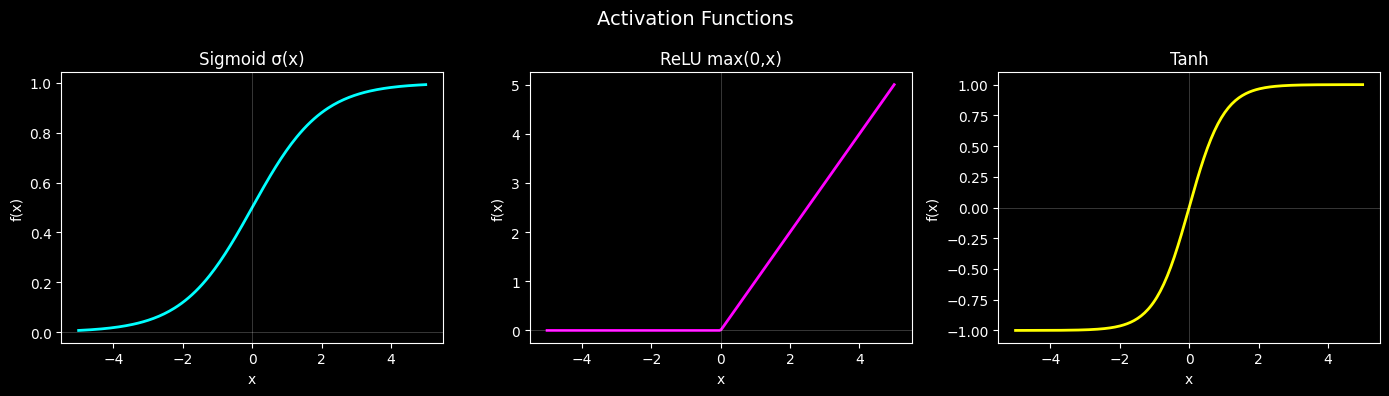

In [ ]:
print("=" * 55)
print("       WHAT IS A NEURAL NETWORK?")
print("=" * 55)
print("""
BIOLOGICAL INSPIRATION:
  Brain neurons receive signals, process them,
  fire if signal is strong enough → output

ARTIFICIAL NEURON (Perceptron):
  1. Takes inputs (x1, x2, ... xn)
  2. Multiplies each by a weight (w1, w2, ... wn)
  3. Adds a bias term (b)
  4. Passes through activation function
  5. Produces output

EQUATION:
  output = activation(w1*x1 + w2*x2 + ... + wn*xn + b)
  output = activation(W·X + b)

ACTIVATION FUNCTIONS — why do we need them?
  Without activation: just a linear model (like LR!)
  With activation: can learn NON-LINEAR patterns!

KEY ACTIVATION FUNCTIONS:
  Sigmoid:  σ(x) = 1/(1+e^(-x))  → output 0-1 (binary!)
  ReLU:     f(x) = max(0, x)      → kills negatives
  Tanh:     f(x) = (e^x-e^-x)/(e^x+e^-x) → output -1 to 1
  Softmax:  normalises to probabilities → multi-class

NEURAL NETWORK = many neurons in layers:
  Input layer  → receives features
  Hidden layers → learn complex patterns
  Output layer → final prediction
""")

# visualise activation functions
x = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Activation Functions", fontsize=14)

for ax, (name, vals, color) in zip(
    axes,
    [
        ("Sigmoid σ(x)", sigmoid, "cyan"),
        ("ReLU max(0,x)", relu, "magenta"),
        ("Tanh", tanh, "yellow"),
    ],
):
    ax.plot(x, vals, color=color, linewidth=2)
    ax.axhline(0, color="white", linewidth=0.5, alpha=0.3)
    ax.axvline(0, color="white", linewidth=0.5, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")

plt.tight_layout()
plt.show()

## 3. Building a Neural Network in PyTorch

In [ ]:
print("=" * 55)
print("       BUILDING A NEURAL NETWORK")
print("=" * 55)


# Define the network
class TitanicNet(nn.Module):
    def __init__(self):
        super(TitanicNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(11, 64),  # input layer: 11 features → 64 neurons
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),  # hidden layer: 64 → 32 neurons
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),  # output layer: 32 → 1 (survived or not)
            nn.Sigmoid(),  # output between 0 and 1
        )

    def forward(self, x):
        return self.network(x).squeeze()


model = TitanicNet()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

       BUILDING A NEURAL NETWORK
TitanicNet(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 2881


## 4. Training the Neural Network

       TRAINING THE NEURAL NETWORK
Epoch  20/100 | Train Loss: 0.5987 | Val Loss: 0.6040
Epoch  40/100 | Train Loss: 0.4770 | Val Loss: 0.4967
Epoch  60/100 | Train Loss: 0.4293 | Val Loss: 0.4541
Epoch  80/100 | Train Loss: 0.4195 | Val Loss: 0.4373
Epoch 100/100 | Train Loss: 0.4072 | Val Loss: 0.4295

Training complete! ✅


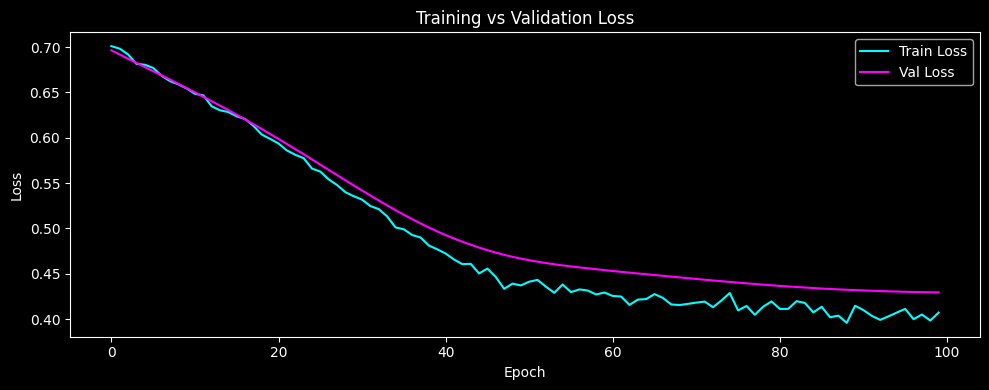

In [ ]:
print("=" * 55)
print("       TRAINING THE NEURAL NETWORK")
print("=" * 55)

# loss function + optimiser
criterion = nn.BCELoss()  # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ── TRAIN ──
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # ── VALIDATE ──
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_test_t)
        val_loss = criterion(y_val_pred, y_test_t)
        val_losses.append(val_loss.item())

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:3d}/100 | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}"
        )

print("\nTraining complete! ✅")

# plot loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color="cyan", label="Train Loss")
ax.plot(val_losses, color="magenta", label="Val Loss")
ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Model Evaluation

       MODEL EVALUATION
Accuracy:  0.8436 (84.4%)
ROC-AUC:   0.8677


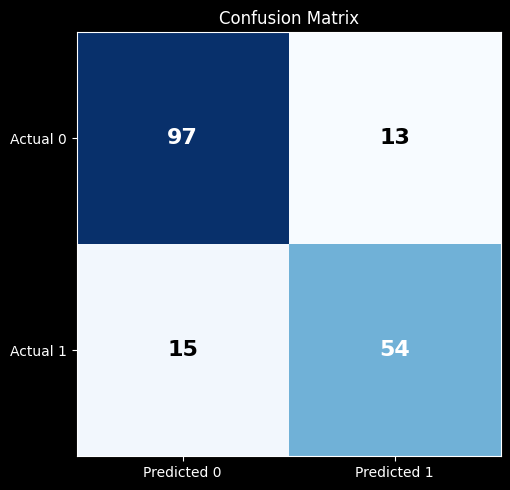


RESULTS SUMMARY:
  True Negatives  (correct 0s): 97
  False Positives (wrong 1s):   13
  False Negatives (wrong 0s):   15
  True Positives  (correct 1s): 54



In [ ]:
print("=" * 55)
print("       MODEL EVALUATION")
print("=" * 55)

model.eval()
with torch.no_grad():
    y_pred_prob = model(X_test_t).numpy()
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_class)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"ROC-AUC:   {auc:.4f}")

# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_class)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted 0", "Predicted 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=16,
            fontweight="bold",
        )
plt.tight_layout()
plt.show()

print(f"""
RESULTS SUMMARY:
  True Negatives  (correct 0s): {cm[0,0]}
  False Positives (wrong 1s):   {cm[0,1]}
  False Negatives (wrong 0s):   {cm[1,0]}
  True Positives  (correct 1s): {cm[1,1]}
""")

## 6. Key Takeaways

In [6]:
print("=" * 55)
print("       DAY 36 — KEY TAKEAWAYS")
print("=" * 55)
print("""
NEURAL NETWORK FUNDAMENTALS:
  ✅ Neuron = weighted inputs + bias + activation
  ✅ Layers: Input → Hidden → Output
  ✅ Activation functions add non-linearity

ACTIVATION FUNCTIONS:
  ✅ Sigmoid  → binary output (0 to 1)
  ✅ ReLU     → hidden layers (kills negatives)
  ✅ Tanh     → hidden layers (-1 to 1)

TRAINING PROCESS:
  ✅ Forward pass  → prediction
  ✅ Loss function → measures error (BCELoss)
  ✅ Backward pass → gradients computed
  ✅ Optimiser     → updates weights (Adam)

PYTORCH WORKFLOW:
  ✅ Define model  → nn.Module class
  ✅ Train loop    → zero_grad → forward
                    → loss → backward → step
  ✅ Evaluate      → model.eval() + no_grad()

OUR RESULTS:
  ✅ Accuracy ~84%
  ✅ Loss converged smoothly
  ✅ No overfitting — train & val loss close
""")

       DAY 36 — KEY TAKEAWAYS

NEURAL NETWORK FUNDAMENTALS:
  ✅ Neuron = weighted inputs + bias + activation
  ✅ Layers: Input → Hidden → Output
  ✅ Activation functions add non-linearity

ACTIVATION FUNCTIONS:
  ✅ Sigmoid  → binary output (0 to 1)
  ✅ ReLU     → hidden layers (kills negatives)
  ✅ Tanh     → hidden layers (-1 to 1)

TRAINING PROCESS:
  ✅ Forward pass  → prediction
  ✅ Loss function → measures error (BCELoss)
  ✅ Backward pass → gradients computed
  ✅ Optimiser     → updates weights (Adam)

PYTORCH WORKFLOW:
  ✅ Define model  → nn.Module class
  ✅ Train loop    → zero_grad → forward
                    → loss → backward → step
  ✅ Evaluate      → model.eval() + no_grad()

OUR RESULTS:
  ✅ Accuracy ~84%
  ✅ Loss converged smoothly
  ✅ No overfitting — train & val loss close

